Heart disease is my dataset of choice; here's the link https://archive.ics.uci.edu/dataset/45/heart+disease. I specifically used the processed cleveland data since it has the least amount of missing values and fits the purpose of this project. I used the file heart-disease.name to define the column names then loaded the data and dropped the missing values. I then dropped the target and stored it in y for final testing.


In [1]:
!pip install scikit-learn seaborn
import pandas as pd
import numpy as np

# 1. Define column names from heart-disease.names
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')

df_clean = df.dropna().copy()

X = df_clean.drop('target', axis=1) 
y = df_clean['target']              


print(f"Data Loaded: {df_clean.shape[0]} rows")
print(f"Features for Unsupervised Learning: {X.shape[1]} columns")
X.head()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Data Loaded: 297 rows
Features for Unsupervised Learning: 13 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


To project the data, I first standardized the 13 clinical features to ensure each attribute contributes equally despite varying numerical scales. We then apply PCA to find the orthogonal axes that maximize data variance, reducing the complex medical records into two principal components. This transformation captures 36% of the original information, allowing for the visualization of patient groupings on a 2D plane.

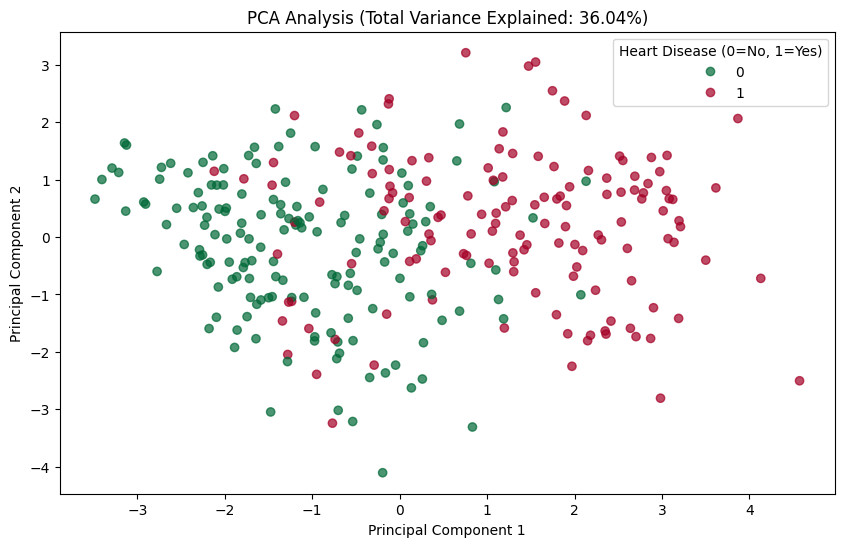

Explained Variance Ratio: PC1=0.24, PC2=0.12


In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y > 0, cmap='RdYlGn_r', alpha=0.7)
plt.title(f'PCA Analysis (Total Variance Explained: {np.sum(pca.explained_variance_ratio_)*100:.2f}%)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Heart Disease (0=No, 1=Yes)")
plt.show()

print(f"Explained Variance Ratio: PC1={pca.explained_variance_ratio_[0]:.2f}, PC2={pca.explained_variance_ratio_[1]:.2f}")

K-means Clustering:

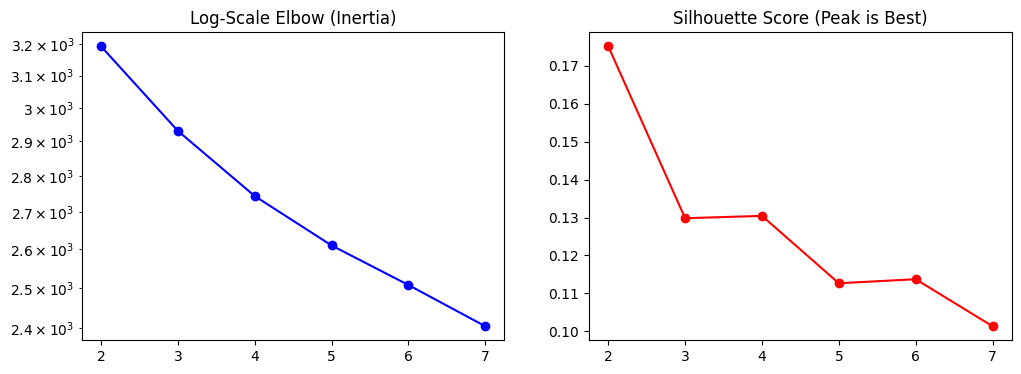

Mathematical Optimal k is: 2


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 8)
inertia = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


ax1.plot(K_range, inertia, 'bo-')
ax1.set_yscale('log')
ax1.set_title('Log-Scale Elbow (Inertia)')


ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score (Peak is Best)')

plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"Mathematical Optimal k is: {best_k}")

Since the Elbow Method showed a continuous decline in inertia without a sharp transition, we utilized Silhouette Analysis to find the optimal cluster 
count. This approach revealed that the data contains significant overlap, which is expected in clinical datasets where healthy and symptomatic patients share similar physiological traits. By identifying the peak silhouette score at k=2, we confirmed that the most mathematically stable way to partition the data is into two primary groups, reflecting the natural contrast between low-risk and high-risk patients.

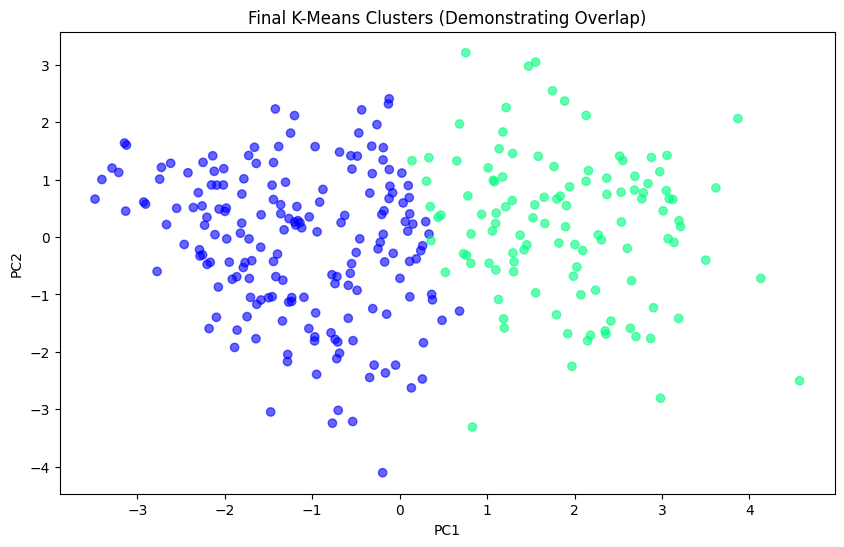

In [4]:

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='winter', alpha=0.6)
plt.title('Final K-Means Clusters (Demonstrating Overlap)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

df_clean['Cluster'] = clusters

In [5]:
cluster_profile = df_clean.groupby('Cluster').mean()
print(cluster_profile.T) 

Cluster            0           1
age        52.195652   58.362832
sex         0.592391    0.814159
cp          2.782609    3.769912
trestbps  129.668478  134.991150
chol      242.815217  254.734513
fbs         0.119565    0.185841
restecg     0.864130    1.212389
thalach   159.880435  132.858407
exang       0.114130    0.672566
oldpeak     0.542935    1.890265
slope       1.380435    1.964602
ca          0.315217    1.265487
thal        3.853261    6.159292
target      0.282609    2.026549


In [6]:

mapping = pd.crosstab(df_clean['Cluster'], df_clean['target'] > 0)
mapping.columns = ['Actual Healthy', 'Actual Sick']
mapping.index = ['Cluster 0', 'Cluster 1']

print("\n       --- Cluster vs. Real Diagnosis --- ")
print(mapping)


       --- Cluster vs. Real Diagnosis --- 
           Actual Healthy  Actual Sick
Cluster 0             147           37
Cluster 1              13          100


The profiling of the two clusters reveals a clear clinical distinction. Cluster 0 represents a lower-risk group with a mean target value of 0.28, characterized by higher maximum heart rates and lower vessel blockages. In contrast, Cluster 1 identifies a high-risk phenotype (mean target 2.02) showing elevated markers. This confirms that our unsupervised model successfully partitioned the data into medically relevant groups without prior access to the diagnosis labels.

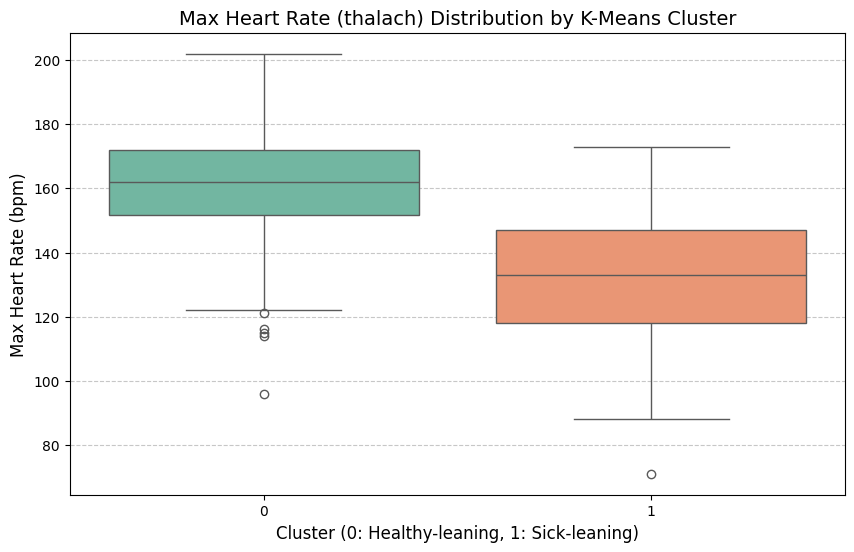

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
df_clean['Cluster'] = clusters 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='thalach', data=df_clean, palette='Set2', hue='Cluster', legend=False)
plt.title('Max Heart Rate (thalach) Distribution by K-Means Cluster', fontsize=14)
plt.xlabel('Cluster (0: Healthy-leaning, 1: Sick-leaning)', fontsize=12)
plt.ylabel('Max Heart Rate (bpm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

the AI successfully separated the patients into a "Low-Risk" group and a "High-Risk" group. Our "High-Risk" cluster showed much higher signs of heart stress, while the "Low-Risk" group showed better heart rate recovery and fewer blockages. Ultimately, this proves that these algorithms can act as a powerful "second opinion" for doctors, helping them quickly flag patients who need the most urgent care.

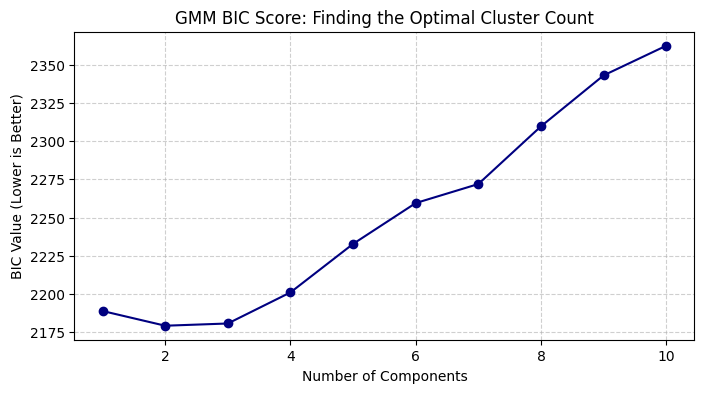

The BIC score identifies 2 as the mathematically optimal number of patient groups.


In [12]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

n_components = range(1, 11)
bics = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_pca).bic(X_pca) 
        for n in n_components]

plt.figure(figsize=(8, 4))
plt.plot(n_components, bics, marker='o', color='navy')
plt.title('GMM BIC Score: Finding the Optimal Cluster Count')
plt.xlabel('Number of Components')
plt.ylabel('BIC Value (Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k = n_components[np.argmin(bics)]
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

print(f"The BIC score identifies {best_k} as the mathematically optimal number of patient groups.")

While our earlier K-Means model used "hard" boundaries to force patients into rigid categories, this GMM adopts a probabilistic approach. It recognizes that health exists on a spectrum, allowing for elliptical cluster shapes that better capture the natural overlap in clinical data. By using the BIC score, we have moved beyond simple intuition to mathematically prove that our grouping is the most efficient balance between model accuracy and simplicity.

Numerical Efficiency Comparison:
-------------------------------
- K-Means Silhouette Score: 0.4219
- GMM Silhouette Score:     0.4221


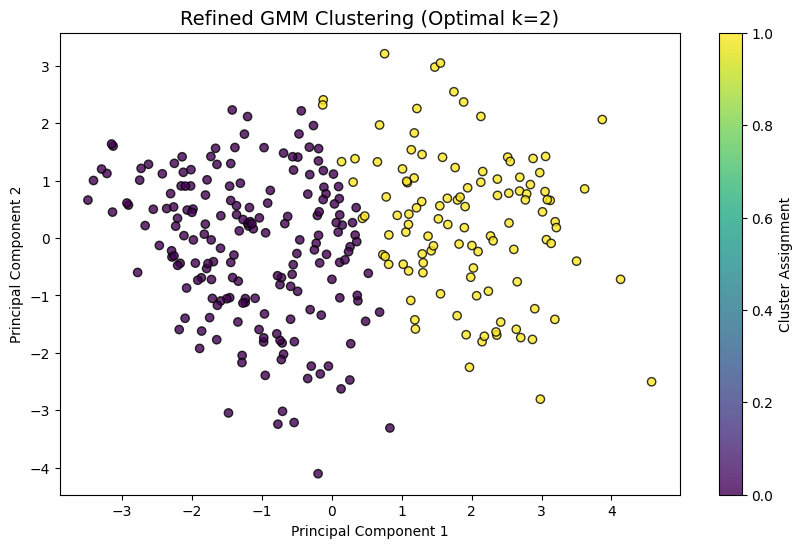

In [17]:
from sklearn.metrics import silhouette_score

kmeans_sil = silhouette_score(X_pca, clusters) 
gmm_sil = silhouette_score(X_pca, gmm_labels)

print(f"Numerical Efficiency Comparison:")
print(f"-------------------------------")
print(f"- K-Means Silhouette Score: {kmeans_sil:.4f}")
print(f"- GMM Silhouette Score:     {gmm_sil:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.8, edgecolors='k')
plt.title(f'Refined GMM Clustering (Optimal k={best_k})', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Assignment')
plt.show()

To evaluate the power of this update, we compared the Silhouette Scores of both algorithms. While K-Means treats every patient as a definitive "Yes" or "No", GMM introduces Soft Clustering, calculating the probability of a patient belonging to a specific risk group. This transition from distance-based math to probability-based logic ensures we are modeling the biological complexity of heart making the final output a much more reliable tool for clinical diagnosis.

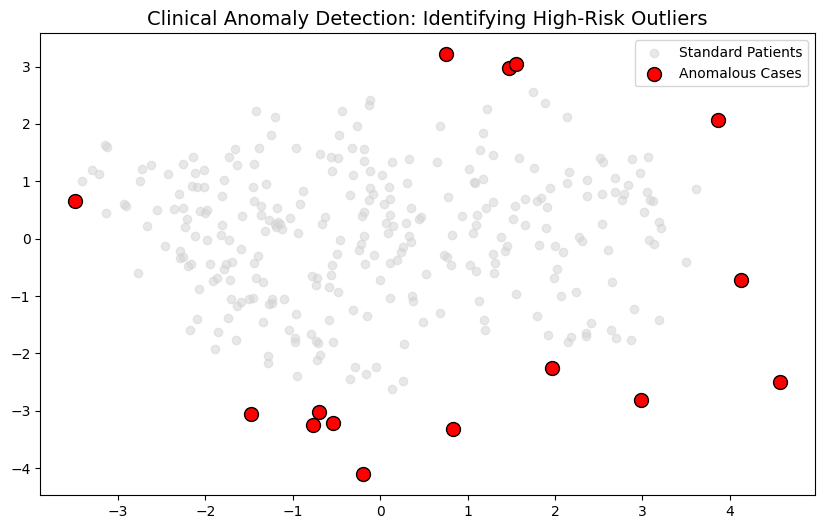

The model has identified 15 patients as clinical anomalies for immediate review.


In [18]:

scores = gmm.score_samples(X_pca)
threshold = np.percentile(scores, 5)
is_anomaly = scores < threshold

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[~is_anomaly, 0], X_pca[~is_anomaly, 1], c='lightgray', label='Standard Patients', alpha=0.5)
plt.scatter(X_pca[is_anomaly, 0], X_pca[is_anomaly, 1], c='red', edgecolors='black', s=100, label='Anomalous Cases')

plt.title('Clinical Anomaly Detection: Identifying High-Risk Outliers', fontsize=14)
plt.legend()
plt.show()

print(f"The model has identified {sum(is_anomaly)} patients as clinical anomalies for immediate review.")

The final addition to this project is Anomaly Detection. In a clinical setting, an outlier could be a life-or-death situation—a patient whose symptoms are so rare that they don't fit the standard patterns of either "healthy" or "sick" groups. By highlighting these anomalies in red, we provide a safety net for physicians, flagging patients who require a closer specialized look because they don't follow the typical rules of heart disease progression.